# Federated Learning on Non-IID MNIST

### Results from Notebook 1

The following results were obtained from independently trained local models in Notebook 1. These values are stored here so they can later be compared with the federated global model.

Each client achieved high accuracy on the digit classes available in its local training data but failed to recognize the classes excluded from its dataset.

In [3]:
# ==============================================================
# Results from Notebook 1: Independent Local Training
# ==============================================================

# Accuracy of each independently trained local model
# on the full MNIST test set

local_global_accuracies = [
    0.6752,  # Client 1: 67.52%
    0.7044,  # Client 2: 70.44%
    0.6979,  # Client 3: 69.79%
]


# Accuracy of each independently trained local model
# on the classes it did not observe during training

local_missing_accuracies = [
    0.0000,  # Client 1 missing digits: 1, 3, 7
    0.0000,  # Client 2 missing digits: 2, 5, 8
    0.0000,  # Client 3 missing digits: 4, 6, 9
]

---

### Before You Begin

This notebook requires the following packages:

- Python 3.12
- PyTorch
- Torchvision
- NumPy
- Pandas
- Matplotlib
- scikit-learn
- Flower with simulation support
- Ray

For reliable execution, Python 3.12 is recommended because Ray may not support the newest Python versions immediately.

## Notebook Overview

**Purpose:** Explore how Federated Learning helps separate clients collaboratively learn from incomplete, non-IID data.

**Dataset:** MNIST handwritten digits (classes 0–9) using the same three client partitions from Notebook 1.

**Experiment:** Train one shared CNN model across three federated clients and combine their local model updates using Federated Averaging (FedAvg).

**Analysis:** Track global loss and accuracy across communication rounds and compare the federated global model with independent local training.

### 1. Library Import

In [4]:
# Run only when the required packages are not installed

# %pip install torch torchvision
# %pip install numpy pandas matplotlib scikit-learn
# %pip install "flwr[simulation]"

In [5]:
# Standard library
import random

# All library imports
from collections import OrderedDict
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms

from flwr.client import NumPyClient
from flwr.common import ndarrays_to_parameters
from flwr.server import ServerConfig
from flwr.server.strategy import FedAvg
from flwr.simulation import start_simulation

import ray
print(ray.__version__)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("All libraries imported successfully.")
print("PyTorch version:", torch.__version__)

2.31.0
All libraries imported successfully.
PyTorch version: 2.5.1+cpu


In [6]:
import sys
import flwr
import packaging
import ray

print("Python:", sys.version)
print("Flower:", flwr.__version__)
print("Packaging:", packaging.__version__)
print("Ray:", ray.__version__)

Python: 3.11.7 | packaged by Anaconda, Inc. | (main, Dec 15 2023, 18:05:47) [MSC v.1916 64 bit (AMD64)]
Flower: 1.16.0
Packaging: 23.1
Ray: 2.31.0


### 2. Load and Inspect the MNIST Dataset

In [7]:
# Convert each image to a normalized PyTorch tensor
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

DATA_DIR = "./MNIST_data/"

# download=True downloads MNIST only when it is not already available
trainset = datasets.MNIST(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=transform,
)

testset = datasets.MNIST(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=transform,
)

### Manual Download Links

Both the image file and its corresponding label file are required for each split:

- **Training images:** [train-images-idx3-ubyte.gz](https://ossci-datasets.s3.amazonaws.com/mnist/train-images-idx3-ubyte.gz)
- **Training labels:** [train-labels-idx1-ubyte.gz](https://ossci-datasets.s3.amazonaws.com/mnist/train-labels-idx1-ubyte.gz)
- **Test images:** [t10k-images-idx3-ubyte.gz](https://ossci-datasets.s3.amazonaws.com/mnist/t10k-images-idx3-ubyte.gz)
- **Test labels:** [t10k-labels-idx1-ubyte.gz](https://ossci-datasets.s3.amazonaws.com/mnist/t10k-labels-idx1-ubyte.gz)

Sources: [Torchvision MNIST documentation](https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html) and [Torchvision MNIST source](https://docs.pytorch.org/vision/stable/_modules/torchvision/datasets/mnist.html). The code above downloads the same files automatically when `download=True`.


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Training samples: {len(trainset):,}")
print(f"Test samples:     {len(testset):,}")
print(f"Classes:          {trainset.classes}")

image, label = trainset[0]
print(f"Image shape:      {tuple(image.shape)}")
print(f"Example label:    {label}")
print(f"CUDA available:   {torch.cuda.is_available()}")
print(f"Selected device:  {device}")

if torch.cuda.is_available():
    print(f"GPU:              {torch.cuda.get_device_name(0)}")

Training samples: 60,000
Test samples:     10,000
Classes:          ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']
Image shape:      (1, 28, 28)
Example label:    5
CUDA available:   False
Selected device:  cpu


#### 2.1 Visualize MNIST Examples

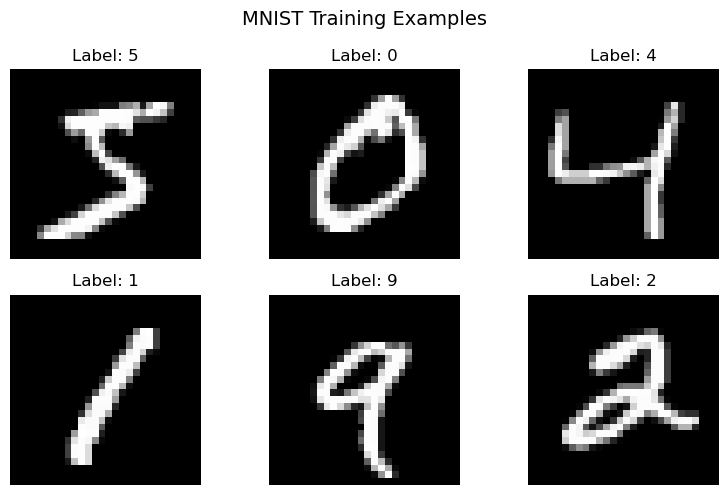

In [9]:
figure, axes = plt.subplots(2, 3, figsize=(8, 5))

for index, axis in enumerate(axes.flat):
    sample_image, sample_label = trainset[index]
    axis.imshow(sample_image.squeeze(), cmap="gray")
    axis.set_title(f"Label: {sample_label}")
    axis.axis("off")

figure.suptitle("MNIST Training Examples", fontsize=14)
plt.tight_layout()
plt.show()

### MNIST Dataset Summary

MNIST is a labeled image-classification dataset of handwritten digits:

- **Training set:** 60,000 images
- **Test set:** 10,000 images
- **Image format:** 28 x 28 grayscale pixels with one channel
- **Classes:** 10 digits, from **0 to 9**
- **Task:** Predict the digit shown in each image

Each sample is an **image-label pair**, rather than a conventional tabular row.

---

### 3. Create the Same Non-IID Client Partitions

In [10]:
# Create three equal random base partitions
partition_size = len(trainset) // 3
partition_sizes = [
    partition_size,
    partition_size,
    len(trainset) - (2 * partition_size),
]

client_1_base, client_2_base, client_3_base = random_split(
    trainset,
    partition_sizes,
    generator=torch.Generator().manual_seed(SEED),
)

print("Base partitions created:")
print(f"Client 1: {len(client_1_base):,} samples")
print(f"Client 2: {len(client_2_base):,} samples")
print(f"Client 3: {len(client_3_base):,} samples")
print(f"Total:    {sum(partition_sizes):,} samples")

Base partitions created:
Client 1: 20,000 samples
Client 2: 20,000 samples
Client 3: 20,000 samples
Total:    60,000 samples


#### 3.1 Partition Strategy

To make the comparison with Notebook 1 fair, we create the **same class-missing, label-skew non-IID partitions**:

1. Randomly divide the 60,000 MNIST training images into three equal base partitions using the same seed, **42**.
2. Remove a different group of digit classes from each client:

   - **Client 1:** missing digits 1, 3, and 7
   - **Client 2:** missing digits 2, 5, and 8
   - **Client 3:** missing digits 4, 6, and 9

Only the training method changes between the notebooks. Notebook 1 trains isolated models; this notebook lets these same clients collaborate through federated learning.

#### 3.2 Helper Functions

**`_get_targets()`** - Extracts all class labels from a MNIST dataset or PyTorch `Subset`. It also preserves the correct label indices when working with a subset.

**`exclude_digits()`** - Creates a new dataset by removing samples belonging to the specified digit classes. We use it to construct class-missing, non-IID client datasets.

**`include_digits()`** - Creates a new dataset containing only the specified digit classes. It is useful for building focused test sets that measure performance on each client’s missing classes.

**`plot_distribution()`** -  Displays the number of samples belonging to each digit class in one dataset. This helps us identify missing classes and class imbalance.

**`compare_distributions()`** - Displays the class distributions of multiple client datasets in one grouped bar chart. It makes the statistical differences between the non-IID clients easy to compare.

**`summarize_dataset()`** - Prints the sample count and the number of examples for each available digit.

In [11]:
def _get_targets(ds):
    """Return a 1D LongTensor of labels for a dataset or Subset."""
    if isinstance(ds, Subset):
        parent = ds.dataset
        idxs = ds.indices
        targets = getattr(parent, "targets", None)
        if isinstance(targets, list):
            targets = torch.tensor(targets)
        if targets is None:
            # very rare fallback
            return torch.tensor([lbl for _, lbl in ds], dtype=torch.long)
        return targets[idxs].clone().long()
    else:
        targets = getattr(ds, "targets", None)
        if isinstance(targets, list):
            targets = torch.tensor(targets)
        if targets is None:
            return torch.tensor([lbl for _, lbl in ds], dtype=torch.long)
        return targets.clone().long()


def exclude_digits(ds, excluded_digits):
    """Return a Subset excluding the specified digits."""
    targets = _get_targets(ds)
    mask = ~np.isin(targets.numpy(), np.array(excluded_digits, dtype=np.int64))
    if isinstance(ds, Subset):
        idxs = np.array(ds.indices)[mask]
        return Subset(ds.dataset, idxs.tolist())
    else:
        idxs = np.nonzero(mask)[0]
        return Subset(ds, idxs.tolist())


def include_digits(ds, included_digits):
    """Return a Subset including only the specified digits."""
    targets = _get_targets(ds)
    mask = np.isin(targets.numpy(), np.array(included_digits, dtype=np.int64))
    if isinstance(ds, Subset):
        idxs = np.array(ds.indices)[mask]
        return Subset(ds.dataset, idxs.tolist())
    else:
        idxs = np.nonzero(mask)[0]
        return Subset(ds, idxs.tolist())

    


# Plotting & Summary Functions


def plot_distribution(ds, title):
    labels = _get_targets(ds).numpy()
    counts = np.bincount(labels, minlength=10)

    plt.figure(figsize=(8, 4))
    plt.bar(range(10), counts, edgecolor='black')
    plt.title(f"Digit Distribution in {title}")
    plt.xlabel("Digit")
    plt.ylabel("Frequency")
    plt.xticks(range(10))
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
    plt.close()


def compare_distributions(datasets, names):
    """Grouped bar chart to compare the three parts side-by-side."""
    all_counts = [np.bincount(_get_targets(ds).numpy(), minlength=10) for ds in datasets]
    x = np.arange(10)
    width = 0.25

    plt.figure(figsize=(10, 4))
    for i, (counts, name) in enumerate(zip(all_counts, names)):
        plt.bar(x + (i-1)*width, counts, width=width, label=name, edgecolor='black')
    plt.xticks(x, list(range(10)))
    plt.xlabel("Digit")
    plt.ylabel("Frequency")
    plt.title("Digit Distribution Across Non-IID Parts")
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
    plt.close()


def summarize(dataset, name):
    """Print the sample count and per-digit distribution."""
    labels = _get_targets(dataset).numpy()
    counts = np.bincount(labels, minlength=10)
    present_counts = {digit: int(count) for digit, count in enumerate(counts) if count > 0}
    print(f"{name}: {len(labels):,} samples")
    print("Digit counts:", present_counts)
    print()

#### 3.3 Build and Check the Client Partitions

In [12]:
# Create the final class-missing non-IID client datasets
client_1_train = exclude_digits(client_1_base, [1, 3, 7])
client_2_train = exclude_digits(client_2_base, [2, 5, 8])
client_3_train = exclude_digits(client_3_base, [4, 6, 9])

summarize(client_1_train, "Client 1 training data (missing 1, 3, 7)")
summarize(client_2_train, "Client 2 training data (missing 2, 5, 8)")
summarize(client_3_train, "Client 3 training data (missing 4, 6, 9)")

Client 1 training data (missing 1, 3, 7): 13,729 samples
Digit counts: {0: 2018, 2: 1943, 4: 1957, 5: 1862, 6: 1995, 8: 1967, 9: 1987}

Client 2 training data (missing 2, 5, 8): 14,284 samples
Digit counts: {0: 1965, 1: 2268, 3: 2009, 4: 1990, 6: 1971, 7: 2087, 9: 1994}

Client 3 training data (missing 4, 6, 9): 14,185 samples
Digit counts: {0: 1940, 1: 2245, 2: 1983, 3: 2102, 5: 1770, 7: 2156, 8: 1989}



#### 3.4 Visualize the Client Distributions

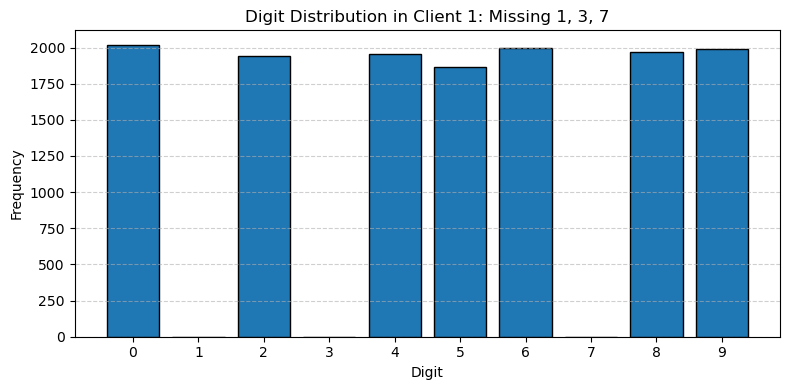

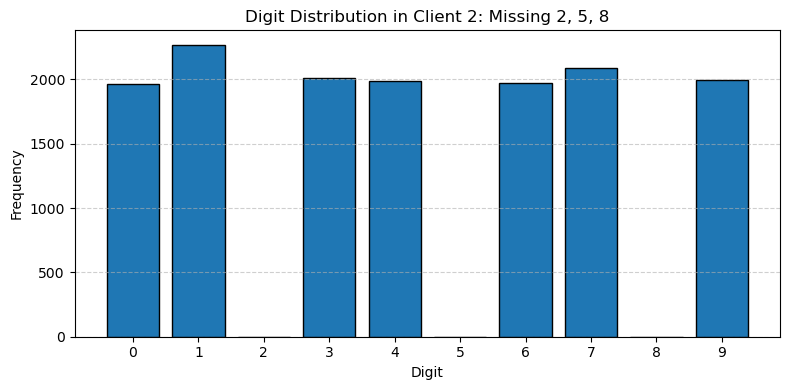

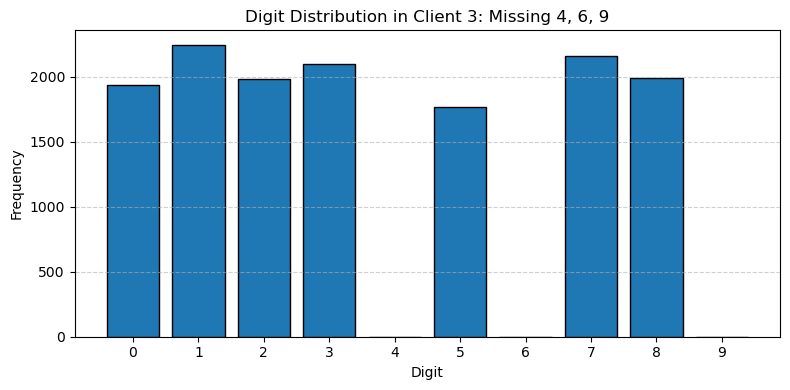

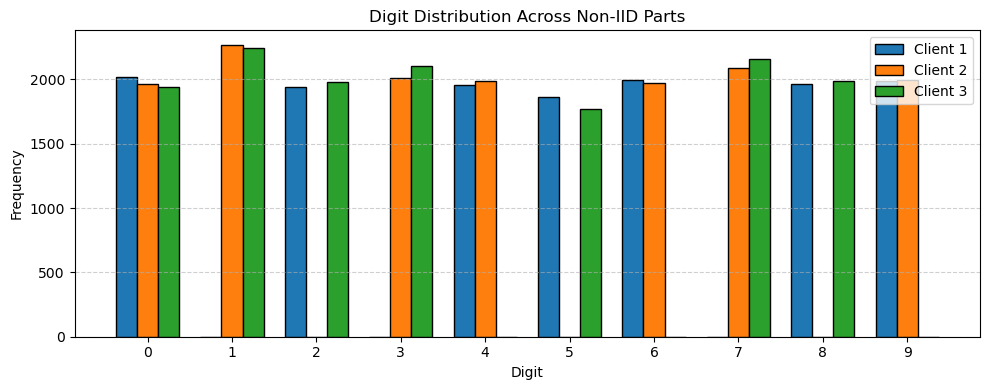

In [13]:
plot_distribution(client_1_train, "Client 1: Missing 1, 3, 7")
plot_distribution(client_2_train, "Client 2: Missing 2, 5, 8")
plot_distribution(client_3_train, "Client 3: Missing 4, 6, 9")

compare_distributions(
    [client_1_train, client_2_train, client_3_train],
    ["Client 1", "Client 2", "Client 3"],
)

---

### 4. Creating Test Subsets

#### 4.1 Seen-Class and Missing-Class Test Sets

In [14]:
# Build focused test sets for classes seen and not seen during local training
client_1_seen_classes_test = exclude_digits(testset, [1, 3, 7])
client_2_seen_classes_test = exclude_digits(testset, [2, 5, 8])
client_3_seen_classes_test = exclude_digits(testset, [4, 6, 9])

client_1_missing_classes_test = include_digits(testset, [1, 3, 7])
client_2_missing_classes_test = include_digits(testset, [2, 5, 8])
client_3_missing_classes_test = include_digits(testset, [4, 6, 9])

print(f"Global test set: {len(testset):,} samples")
print()
print("Client 1 | seen classes: "
      f"{len(client_1_seen_classes_test):,} | missing classes [1, 3, 7]: "
      f"{len(client_1_missing_classes_test):,}")
print("Client 2 | seen classes: "
      f"{len(client_2_seen_classes_test):,} | missing classes [2, 5, 8]: "
      f"{len(client_2_missing_classes_test):,}")
print("Client 3 | seen classes: "
      f"{len(client_3_seen_classes_test):,} | missing classes [4, 6, 9]: "
      f"{len(client_3_missing_classes_test):,}")

Global test set: 10,000 samples

Client 1 | seen classes: 6,827 | missing classes [1, 3, 7]: 3,173
Client 2 | seen classes: 7,102 | missing classes [2, 5, 8]: 2,898
Client 3 | seen classes: 7,051 | missing classes [4, 6, 9]: 2,949


Each client now has two focused evaluation sets: one containing the digit classes it **saw during training** and one containing the classes that were **missing from its training data**. This makes the model's learned knowledge and blind spots directly comparable.

#### 4.2 Global Test Set

In [15]:
# Inspect the complete test set used to evaluate every client model
print("Global test set")
print(f"Samples: {len(testset):,}")
print("Digits:  0-9")

test_image, test_label = testset[0]
print(f"Image shape: {tuple(test_image.shape)}")
print(f"Example label: {test_label}")

Global test set
Samples: 10,000
Digits:  0-9
Image shape: (1, 28, 28)
Example label: 7


The **global test set** is the complete official MNIST test split. It contains all digits from 0 to 9 and is used unchanged for every client model.

---

### 5. Dataset Partitioning Summary

In [16]:
training_partitions = [client_1_train, client_2_train, client_3_train]
retained_training_samples = sum(len(dataset) for dataset in training_partitions)
discarded_training_samples = len(trainset) - retained_training_samples

print("TRAINING PARTITIONS")
print(f"Client 1 (missing 1, 3, 7): {len(client_1_train):,} samples")
print(f"Client 2 (missing 2, 5, 8): {len(client_2_train):,} samples")
print(f"Client 3 (missing 4, 6, 9): {len(client_3_train):,} samples")
print(f"Total retained:              {retained_training_samples:,} samples")
print(
    f"Removed by class filtering:  {discarded_training_samples:,} samples "
    f"({discarded_training_samples / len(trainset) * 100:.1f}%)"
)

print()
print("EVALUATION DATASETS")
print(f"Global test set (digits 0-9): {len(testset):,} samples")
print(
    f"Client 1 | seen: {len(client_1_seen_classes_test):,} | "
    f"missing [1, 3, 7]: {len(client_1_missing_classes_test):,}"
)
print(
    f"Client 2 | seen: {len(client_2_seen_classes_test):,} | "
    f"missing [2, 5, 8]: {len(client_2_missing_classes_test):,}"
)
print(
    f"Client 3 | seen: {len(client_3_seen_classes_test):,} | "
    f"missing [4, 6, 9]: {len(client_3_missing_classes_test):,}"
)

TRAINING PARTITIONS
Client 1 (missing 1, 3, 7): 13,729 samples
Client 2 (missing 2, 5, 8): 14,284 samples
Client 3 (missing 4, 6, 9): 14,185 samples
Total retained:              42,198 samples
Removed by class filtering:  17,802 samples (29.7%)

EVALUATION DATASETS
Global test set (digits 0-9): 10,000 samples
Client 1 | seen: 6,827 | missing [1, 3, 7]: 3,173
Client 2 | seen: 7,102 | missing [2, 5, 8]: 2,898
Client 3 | seen: 7,051 | missing [4, 6, 9]: 2,949


| Dataset | Role | Digit classes |
| --- | --- | --- |
| **client_1_train** | Client 1 training data | 0, 2, 4, 5, 6, 8, 9 (missing 1, 3, 7) |
| **client_2_train** | Client 2 training data | 0, 1, 3, 4, 6, 7, 9 (missing 2, 5, 8) |
| **client_3_train** | Client 3 training data | 0, 1, 2, 3, 5, 7, 8 (missing 4, 6, 9) |
| **testset** | Global evaluation | All digits, 0-9 |
| **client_1_seen_classes_test** | Tests Client 1's learned classes | 0, 2, 4, 5, 6, 8, 9 |
| **client_1_missing_classes_test** | Tests Client 1's blind spots | 1, 3, 7 |
| **client_2_seen_classes_test** | Tests Client 2's learned classes | 0, 1, 3, 4, 6, 7, 9 |
| **client_2_missing_classes_test** | Tests Client 2's blind spots | 2, 5, 8 |
| **client_3_seen_classes_test** | Tests Client 3's learned classes | 0, 1, 2, 3, 5, 7, 8 |
| **client_3_missing_classes_test** | Tests Client 3's blind spots | 4, 6, 9 |

**Important:** Class filtering intentionally removes some training images. The experiment retains 42,198 of the original 60,000 training samples; the removed images are not reassigned to another client.

---

### 6. CNN Model

Each client trains a **local copy of the shared CNN model** using only its local non-IID training partition. The clients do not share raw data. Instead, they send their updated model parameters to the server, where the updates are aggregated to improve the global model.

**Workflow**

1. Define one global CNN architecture and a common set of hyperparameters.

2. Define Federated Learning Setup 

3. Send the current global model to all clients.

4. Train the model locally on each client’s private dataset.

5. Send the updated model parameters to the server and aggregate them using Federated Averaging (FedAvg).

5. Evaluate the updated global model on the full test set and on the missing digit classes.


#### 6.1 Model Configurations

| **Component**             | **Value**        | **Purpose / Why Used**                                                                    |
| ------------------------- | ---------------- | ----------------------------------------------------------------------------------------- |
| **Optimizer**             | Adam             | Handles noisy, non-IID gradients effectively and converges faster without heavy tuning.   |
| **Loss Function**         | CrossEntropyLoss | Standard loss for multi-class classification problems like MNIST.                         |
| **Epochs per Client**     | 2                | Allows sufficient local learning while avoiding overfitting during each FL round.         |
| **Batch Size**            | 128              | Provides stable gradient updates and efficient GPU/CPU utilization.                       |
| **Learning Rate**         | 0.001            | A well-balanced rate for Adam, ensuring steady convergence.                               |
| **Weight Decay**          | 0.0001           | Adds light L2 regularization to prevent overfitting on small local datasets.              |
| **Dropout (FC Layer)**    | 0.25             | Improves generalization by randomly deactivating neurons during training.                 |
| **Conv Filters**          | 32, 64           | Standard LeNet-like architecture-enough capacity to capture features without overfitting. |
| **Kernel Size / Padding** | 5x5 (pad=2)      | Increases receptive field while preserving spatial dimensions pre-pooling.                |
| **Pooling**               | 2x2 Max Pool     | Reduces spatial dimensions (28->14->7) to control parameters and computation.             |
| **Hidden Units**          | 128              | Balances model expressiveness and computational efficiency.                               |
| **Seed**                  | 42               | Ensures reproducibility across training and evaluation runs.                              |


In [17]:
# -----------------------------
# ⚙️ Config (hyperparameters)
# -----------------------------

CONFIG = {
    "seed": 42,
    "batch_size": 128,
    "epochs": 2,
    "learning_rate": 0.001,
    "weight_decay": 0.0001,
    "dropout": 0.25,
}

_ = torch.manual_seed(CONFIG["seed"])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CONFIG["seed"])


def get_device():
    """Select a CUDA GPU when available; otherwise use the CPU."""
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

**Configuration terms**

- **Seed:** Fixes random operations so the experiment can be reproduced.

- **Batch size:** Number of training images processed before one model update.

- **Epochs:** Number of complete passes through a client's training dataset.

- **Learning rate:** Controls how much the model parameters change during each update.

- **Weight decay:** Adds a small penalty that helps reduce overfitting.

- **Dropout:** Randomly disables some neurons during training to improve generalization.

- **`get_device()`** selects a CUDA GPU when one is available; otherwise, it uses the CPU.

#### 6.2. CNN Architecture

`MNISTCNN` receives a grayscale image with shape `1 x 28 x 28` and returns 10 logits, one for each digit class. Two convolution and pooling stages learn image features; two fully connected layers perform classification.

In [18]:
# -----------------------------
# 🧩 Model (LeNet-style CNN)
# -----------------------------
class MNISTCNN(nn.Module):
    def __init__(self, dropout=0.25):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=5, padding=2)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, images):
        features = self.pool(F.relu(self.conv1(images)))
        features = self.pool(F.relu(self.conv2(features)))
        features = torch.flatten(features, start_dim=1)
        features = self.dropout(F.relu(self.fc1(features)))
        return self.fc2(features)


print("✅ Model ready. Device:", get_device())

✅ Model ready. Device: cpu


In [19]:
def count_trainable_parameters(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

In [20]:
example_model = MNISTCNN(dropout=CONFIG["dropout"])

print(example_model)
print(f"Device: {get_device()}")
print(f"Trainable parameters: {count_trainable_parameters(example_model):,}")

MNISTCNN(
  (conv1): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv2): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
Device: cpu
Trainable parameters: 454,922


The output summarizes the CNN structure: 

- two convolutional layers, 

- two fully connected layers, 

- dropout (during training, the model randomly "turns off" or ignores 25% of the neurons in that layer on every pass)

- **454,922 trainable parameters** (weights and biases).

- "`Device: cuda`" means the model will run on the GPU, where these parameters will be updated during training.

##### CNN Architecture Breakdown

The model has **four learnable layers**: two convolutional layers and two fully connected layers. ReLU, pooling, flattening, and dropout are processing operations; they do not contain trainable weights.

| Step | Operation | Output shape per image | Units and activation | Purpose |
| --- | --- | --- | --- | --- |
| Input | MNIST image | `1 x 28 x 28` | 1 grayscale channel | Provides the image pixels. |
| 1 | `conv1` | `32 x 28 x 28` | 32 filters, followed by ReLU | Learns simple features such as edges and strokes. |
| 2 | First max pooling | `32 x 14 x 14` | No activation | Halves the height and width. |
| 3 | `conv2` | `64 x 14 x 14` | 64 filters, followed by ReLU | Learns more complex digit patterns. |
| 4 | Second max pooling | `64 x 7 x 7` | No activation | Halves the spatial dimensions again. |
| 5 | Flatten | `3,136` | `64 x 7 x 7 = 3,136` features | Converts feature maps into one feature vector. |
| 6 | `fc1` | `128` | 128 neurons, followed by ReLU and dropout | Combines the extracted features. |
| 7 | `fc2` | `10` | 10 output neurons, no explicit activation | Produces one logit for each digit from 0 to 9. |

#### 6.3. Training & Evaluation Functions

The next two code cells define the reusable functions used later in the notebook:

1. `train_model()` trains one CNN on one client's dataset and reports loss and accuracy after each epoch.

2. `evaluate_model()` tests a trained CNN and returns its accuracy, with optional true and predicted labels for confusion-matrix analysis.

In [21]:
def train_model(
    model,
    dataset,
    epochs=CONFIG["epochs"],
    batch_size=CONFIG["batch_size"],
    learning_rate=CONFIG["learning_rate"],
    weight_decay=CONFIG["weight_decay"],
):
    device = get_device()
    model = model.to(device)
    data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    loss_function = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        correct_predictions = 0
        sample_count = 0

        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            logits = model(images)
            loss = loss_function(logits, labels)
            loss.backward()
            optimizer.step()

            batch_size_current = labels.size(0)
            total_loss += loss.item() * batch_size_current
            correct_predictions += (logits.argmax(dim=1) == labels).sum().item()
            sample_count += batch_size_current

        average_loss = total_loss / sample_count
        accuracy = correct_predictions / sample_count
        print(
            f"Epoch {epoch}/{epochs} | "
            f"loss: {average_loss:.4f} | accuracy: {accuracy * 100:.2f}%"
        )

    return model

In [22]:
def evaluate_model(model, dataset, batch_size=256, return_predictions=False):
    device = get_device()
    model = model.to(device)
    model.eval()
    data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    true_labels = []
    predicted_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            logits = model(images.to(device))
            predictions = logits.argmax(dim=1).cpu()
            true_labels.append(labels)
            predicted_labels.append(predictions)

    y_true = torch.cat(true_labels).numpy()
    y_pred = torch.cat(predicted_labels).numpy()
    accuracy = accuracy_score(y_true, y_pred)

    if return_predictions:
        return (y_true, y_pred), accuracy
    return None, accuracy

---

### 7. Federated Learning System

**Type of Federated Learning:** Cross-silo, synchronous Federated Learning 

**Aggregation:** Federated Averaging (FedAvg)

Three clients train local copies of the shared CNN model using their own non-IID MNIST datasets. After each communication round, the clients send their updated model parameters to the central server. The server aggregates these updates using FedAvg to create an improved global model.

#### 7.1. FL Configuration

| Parameter                         | Value                         |                       Used? | Notes                                                                                                                                                       |
| --------------------------------- | ----------------------------- | --------------------------: | ----------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **FL Strategy**                   | FedAvg                        |                     **Yes** | `strategy = FedAvg(...)`                                                                                                                                    |
| **Number of Clients**             | 3                             |                     **Yes** | `num_clients=len(train_sets)` where `train_sets=[part1, part2, part3]`                                                                                      |
| **Number of Rounds**              | 3                             |                     **Yes** | `ServerConfig(num_rounds=3)`                                                                                                                                |
| **Model Used**                    | MNISTCNN (LeNet-style CNN)    |                     **Yes** | Same model for clients and server init                                                                                                                      |
| **Fraction of Clients per Round** | 1.0                           |                     **Yes** | `fraction_fit=1.0` (all clients every round)                                                                                                                |
| **Fraction for Evaluation**       | 0.0                           |                     **Yes** | `fraction_evaluate=0.0` (centralized eval on server)                                                                                                        |
| **Local Epochs per Client**       | 2                             |                     **Yes** | `CONFIG["epochs"]=2`                                                                                                                                        |
| **Server Evaluation Function**    | Custom `server_evaluate()`    | **Yes (name = `evaluate`)** | We used a function named **`evaluate`** that computes CE loss, accuracies on whole test set and subsets, and saves the confusion matrix in the final round. |


In [23]:
# ==============================================================
# 7.1 Federated Learning Configuration
# ==============================================================

NUM_CLIENTS = 3       # Number of federated clients
NUM_ROUNDS = 3        # Number of communication rounds
LOCAL_EPOCHS = 2      # Local training epochs per client in each round

# Computing resources assigned to each client
CLIENT_RESOURCES = {
    "num_cpus": 2,
    "num_gpus": 0.0,
}

print("Federated Learning Configuration")
print("--------------------------------")
print(f"Number of clients: {NUM_CLIENTS}")
print(f"Communication rounds: {NUM_ROUNDS}")
print(f"Local epochs per round: {LOCAL_EPOCHS}")
print(
    f"Total local epochs per client: "
    f"{NUM_ROUNDS * LOCAL_EPOCHS}"
)

Federated Learning Configuration
--------------------------------
Number of clients: 3
Communication rounds: 3
Local epochs per round: 2
Total local epochs per client: 6



We use three federated clients and train the global model for three communication rounds.

During each round, every client trains its local model for two epochs. Therefore, each client performs a total of six local training epochs:

**3 communication rounds × 2 local epochs = 6 total local epochs**

#### 7.2 Exchange Model Parameters

During Federated Learning, clients do not send raw training data to the server.

Instead, the server sends the global model parameters to each client. After local training, each client sends its updated model parameters back to the server.

The following functions convert model parameters between PyTorch and Flower.

In [24]:
# ==============================================================
# 7.2 Exchange Model Parameters
# ==============================================================

def get_weights(model):
    """
    Extract model parameters from a PyTorch model
    and convert them into NumPy arrays for Flower.
    """
    return [
        parameter.cpu().numpy()
        for parameter in model.state_dict().values()
    ]


def set_weights(model, parameters):
    """
    Load model parameters received from Flower
    into a PyTorch model.
    """
    parameter_pairs = zip(
        model.state_dict().keys(),
        parameters,
    )

    state_dict = OrderedDict(
        {
            name: torch.tensor(value)
            for name, value in parameter_pairs
        }
    )

    model.load_state_dict(
        state_dict,
        strict=True,
    )

**Model Parameter Exchange**

PyTorch model -----> get_weights() -----> NumPy model parameters -----> Sent through Flower -----> set_weights() -----> PyTorch model

#### 7.3 Create a Federated Client

Each federated client:

1. Receives the current global model parameters from the server.

2. Trains the model on its own local non-IID dataset.

3. Sends the updated model parameters back to the server.

The raw training data always remains on the client.

In [25]:
# ==============================================================
# 7.3 Create a Federated Client
# ==============================================================

class FlowerClient(NumPyClient):

    def __init__(self, model, trainset):
        """
        Store the client's local model and local training dataset.
        """
        self.model = model
        self.trainset = trainset

    def fit(self, parameters, config):
        """
        Receive the global model, train locally,
        and return the updated model parameters.
        """

        # Step 1: Receive the global model parameters
        set_weights(
            self.model,
            parameters,
        )

        # Step 2: Train locally for 2 epochs
        train_model(
            self.model,
            self.trainset,
            epochs=LOCAL_EPOCHS,
        )

        # Step 3: Send updated parameters back to the server
        return (
            get_weights(self.model),
            len(self.trainset),
            {},
        )

**Core Client Workflow**

Receive global model -----> Train locally -----> Return updated model

#### 7.4 Create the Federated Clients

We now create the three federated clients.

Each client uses:

- The same CNN architecture.
- Its own local non-IID training dataset.
- The same local training configuration.

Although the model architecture is identical, each client receives a different local dataset.

In [26]:
# Group the three client training datasets

train_sets = [
    client_1_train,
    client_2_train,
    client_3_train,
]

In [27]:
# ==============================================================
# 7.4 Create the Federated Clients
# ==============================================================

def create_client_function(client_datasets):
    """
    Create a client function that has access
    to the previously prepared local datasets.
    """

    def client_fn(context):
        """
        Create one federated client.
        """

        # Get the client ID: 0, 1, or 2
        client_index = int(
            context.node_config["partition-id"]
        )

        # Create a fresh CNN model
        model = MNISTCNN(
            dropout=CONFIG["dropout"]
        )

        # Assign the corresponding Non-IID dataset
        local_trainset = client_datasets[
            client_index
        ]

        # Create and return the Flower client
        return FlowerClient(
            model=model,
            trainset=local_trainset,
        ).to_client()

    return client_fn


# Create the client function
client_fn = create_client_function(
    train_sets
)

#### 7.5 Evaluate the Global Model


After each communication round, the server evaluates the updated global model on the full MNIST test set.

This allows us to track how the global loss and accuracy change across communication rounds.

In [28]:
# ==============================================================
# Helper: Compute Cross-Entropy Loss
# ==============================================================

def compute_test_loss(
    model,
    dataset,
    batch_size=256,
):
    """
    Compute the average cross-entropy loss
    on a given test dataset.
    """

    device = get_device()

    model = model.to(device)
    model.eval()

    test_loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
    )

    criterion = nn.CrossEntropyLoss()

    total_loss = 0.0
    total_samples = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            predictions = model(images)

            loss = criterion(
                predictions,
                labels,
            )

            batch_size_current = labels.size(0)

            total_loss += (
                loss.item()
                * batch_size_current
            )

            total_samples += (
                batch_size_current
            )

    average_loss = (
        total_loss
        / total_samples
    )

    return average_loss

In [29]:
# ==============================================================
# 7.5 Evaluate the Global Model
# ==============================================================

# Store the latest global model parameters
final_global_parameters = None


def evaluate_global_model(
    server_round,
    parameters,
    config,
):
    """
    Evaluate the current global model
    on the full MNIST test set.
    """

    global final_global_parameters

    # Create the global CNN model
    global_model = MNISTCNN(
        dropout=CONFIG["dropout"]
    )

    # Load the current global parameters
    set_weights(
        global_model,
        parameters,
    )

    # Save the latest global parameters
    final_global_parameters = parameters

    # Calculate global test loss
    global_loss = compute_test_loss(
        global_model,
        testset,
    )

    # Calculate global test accuracy
    _, global_accuracy = evaluate_model(
        global_model,
        testset,
    )

    # Display the results
    print(
        f"Round {server_round} | "
        f"Loss: {global_loss:.4f} | "
        f"Accuracy: {global_accuracy:.4f}"
    )

    # Return results to Flower
    return float(global_loss), {
        "accuracy": float(global_accuracy)
    }

Aggregated global model -----> Full MNIST test set -----> Global loss + global accuracy

#### 7.6 Configure Federated Averaging



The server uses Federated Averaging (FedAvg) to combine the model updates received from all three clients.

In every communication round:

1. All three clients participate in local training.
2. The server aggregates their updated model parameters.
3. The new global model is evaluated on the full MNIST test set.

In [30]:
# ==============================================================
# 7.6 Configure Federated Averaging
# ==============================================================

# Create the initial global CNN model
initial_global_model = MNISTCNN(
    dropout=CONFIG["dropout"]
)

# Convert the initial model weights into Flower parameters
initial_parameters = ndarrays_to_parameters(
    get_weights(initial_global_model)
)

# Configure the FedAvg strategy
strategy = FedAvg(

    # All clients participate in every training round
    fraction_fit=1.0,

    # Client-side evaluation is disabled
    fraction_evaluate=0.0,

    # Initial parameters of the global model
    initial_parameters=initial_parameters,

    # Server-side evaluation after every round
    evaluate_fn=evaluate_global_model,
)

# Set the number of communication rounds
server_config = ServerConfig(
    num_rounds=NUM_ROUNDS
)

#### 7.7 Start the Federated Learning Simulation

We now start the federated training process.

During each communication round:

1. The server sends the current global model to all three clients.

2. Each client trains locally for two epochs.

3. The clients send their updated model parameters back to the server.

4. The server aggregates the updates using FedAvg.

5. The updated global model is evaluated on the full MNIST test set.

In [31]:
# ==============================================================
# 7.7 Start the Federated Learning Simulation
# ==============================================================

print("Starting Federated Learning simulation...\n")

history = start_simulation(
    client_fn=client_fn,
    num_clients=NUM_CLIENTS,
    config=server_config,
    strategy=strategy,
    client_resources=CLIENT_RESOURCES,
)

print("\nFederated Learning simulation completed.")

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        


Starting Federated Learning simulation...



INFO :      Starting Flower simulation, config: num_rounds=3, no round_timeout
2026-07-25 09:30:46,040	INFO worker.py:1771 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'CPU': 8.0, 'node:__internal_head__': 1.0, 'node:127.0.0.1': 1.0, 'memory': 2303014503.0, 'object_store_memory': 1151507251.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 2, 'num_gpus': 0.0}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 4 actors
INFO :      [INIT]
INFO :      Using initial global parameters provided by strategy
INFO :      Starting evaluation of initial global parameters
INFO :      initial parameters (loss, other metrics): 2.305920323944092, {'accuracy': 0.1035}
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 3 clients (out of 3)


Round 0 | Loss: 2.3059 | Accuracy: 0.1035
(ClientAppActor pid=22364) Epoch 1/2 | loss: 0.3463 | accuracy: 88.27%
(ClientAppActor pid=22364) Epoch 2/2 | loss: 0.0776 | accuracy: 97.66% [repeated 3x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)


INFO :      aggregate_fit: received 3 results and 0 failures
INFO :      fit progress: (1, 0.5062335831165313, {'accuracy': 0.9223}, 56.72311380004976)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 2]
INFO :      configure_fit: strategy sampled 3 clients (out of 3)


Round 1 | Loss: 0.5062 | Accuracy: 0.9223
(ClientAppActor pid=22364) Epoch 1/2 | loss: 0.0906 | accuracy: 97.37% [repeated 3x across cluster]
(ClientAppActor pid=22364) Epoch 2/2 | loss: 0.0441 | accuracy: 98.61% [repeated 3x across cluster]


INFO :      aggregate_fit: received 3 results and 0 failures
INFO :      fit progress: (2, 0.07077450015470385, {'accuracy': 0.9804}, 103.39726940006949)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 3]
INFO :      configure_fit: strategy sampled 3 clients (out of 3)


Round 2 | Loss: 0.0708 | Accuracy: 0.9804
(ClientAppActor pid=26656) Epoch 1/2 | loss: 0.0518 | accuracy: 98.28% [repeated 3x across cluster]
(ClientAppActor pid=26656) Epoch 2/2 | loss: 0.0327 | accuracy: 98.91% [repeated 3x across cluster]


INFO :      aggregate_fit: received 3 results and 0 failures
INFO :      fit progress: (3, 0.05937577889543027, {'accuracy': 0.9833}, 150.05873779999092)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 3 round(s) in 150.06s
INFO :      	History (loss, centralized):
INFO :      		round 0: 2.305920323944092
INFO :      		round 1: 0.5062335831165313
INFO :      		round 2: 0.07077450015470385
INFO :      		round 3: 0.05937577889543027
INFO :      	History (metrics, centralized):
INFO :      	{'accuracy': [(0, 0.1035), (1, 0.9223), (2, 0.9804), (3, 0.9833)]}
INFO :      


Round 3 | Loss: 0.0594 | Accuracy: 0.9833

Federated Learning simulation completed.


**History** variable stores the global loss and accuracy recorded during the communication rounds. We will use it in the next section to visualize the FL training results.

### 7.8 Visualize Federated Learning Results

We visualize these results to observe how the global model improves during federated training.

In [32]:
# ==============================================================
# 7.8 Visualize Federated Learning Results
# ==============================================================

# Extract global loss values
loss_results = history.losses_centralized

loss_rounds = [
    round_number
    for round_number, _ in loss_results
]

global_losses = [
    loss
    for _, loss in loss_results
]


# Extract global accuracy values
accuracy_results = history.metrics_centralized["accuracy"]

accuracy_rounds = [
    round_number
    for round_number, _ in accuracy_results
]

global_accuracies = [
    accuracy
    for _, accuracy in accuracy_results
]

7.8.1. Global Loss Plot

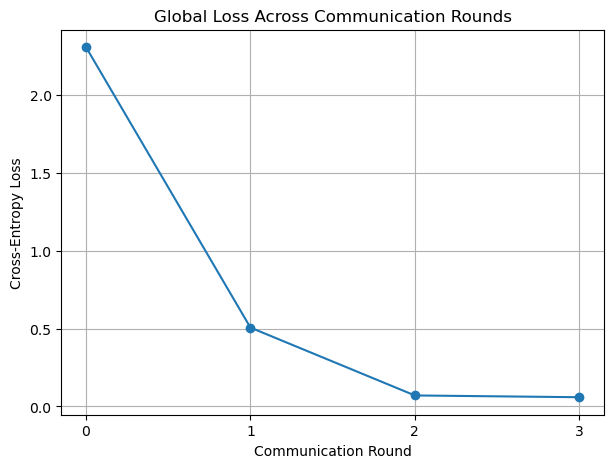

In [33]:
# Plot global loss

plt.figure(figsize=(7, 5))

plt.plot(
    loss_rounds,
    global_losses,
    marker="o",
)

plt.title(
    "Global Loss Across Communication Rounds"
)

plt.xlabel(
    "Communication Round"
)

plt.ylabel(
    "Cross-Entropy Loss"
)

plt.xticks(
    loss_rounds
)

plt.grid()

plt.show()

7.8.2. Global Accuracy Plot

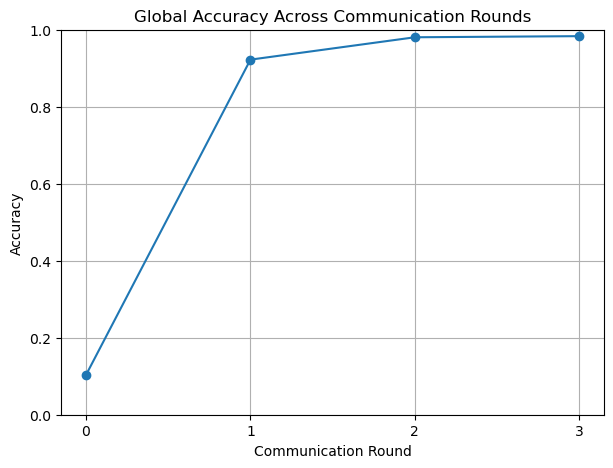

In [34]:
# Plot global accuracy

plt.figure(figsize=(7, 5))

plt.plot(
    accuracy_rounds,
    global_accuracies,
    marker="o",
)

plt.title(
    "Global Accuracy Across Communication Rounds"
)

plt.xlabel(
    "Communication Round"
)

plt.ylabel(
    "Accuracy"
)

plt.xticks(
    accuracy_rounds
)

plt.ylim(
    0,
    1,
)

plt.grid()

plt.show()

#### 7.9 Evaluate the Final Global Model

After the final communication round, we evaluate the federated global model on:

- The full MNIST test set.
- Client 1's missing digit classes.
- Client 2's missing digit classes.
- Client 3's missing digit classes.

This helps us determine whether collaborative federated training reduced the blind spots observed during independent local training.

In [35]:
# ==============================================================
# 7.9 Evaluate the Final Global Model
# ==============================================================

# Create the final global CNN model
final_global_model = MNISTCNN(
    dropout=CONFIG["dropout"]
)

# Load the final federated parameters
set_weights(
    final_global_model,
    final_global_parameters,
)


# --------------------------------------------------------------
# Evaluate on the full MNIST test set
# --------------------------------------------------------------

_, global_accuracy = evaluate_model(
    final_global_model,
    testset,
)


# --------------------------------------------------------------
# Evaluate on the missing-class test subsets
# --------------------------------------------------------------

_, client_1_missing_accuracy = evaluate_model(
    final_global_model,
    client_1_missing_classes_test,
)

_, client_2_missing_accuracy = evaluate_model(
    final_global_model,
    client_2_missing_classes_test,
)

_, client_3_missing_accuracy = evaluate_model(
    final_global_model,
    client_3_missing_classes_test,
)


# --------------------------------------------------------------
# Display the results
# --------------------------------------------------------------

print("Final Federated Global Model")
print("--------------------------------------------")

print(
    f"Full MNIST Test Accuracy: "
    f"{global_accuracy:.4f}"
)

print(
    f"Client 1 Missing Classes Accuracy: "
    f"{client_1_missing_accuracy:.4f}"
)

print(
    f"Client 2 Missing Classes Accuracy: "
    f"{client_2_missing_accuracy:.4f}"
)

print(
    f"Client 3 Missing Classes Accuracy: "
    f"{client_3_missing_accuracy:.4f}"
)

Final Federated Global Model
--------------------------------------------
Full MNIST Test Accuracy: 0.9833
Client 1 Missing Classes Accuracy: 0.9820
Client 2 Missing Classes Accuracy: 0.9817
Client 3 Missing Classes Accuracy: 0.9810


#### 7.10 Compare Independent Local Training and Federated Learning

We now compare the independently trained local models from Notebook 1 with the federated global model.

Both experiments use:

- The same CNN architecture.
- The same non-IID client datasets.
- The same total number of local training epochs per client.

We compare performance on:

1. The full MNIST test set to measure overall accuracy.
2. The missing-class test subsets to examine whether Federated Learning reduced the blind spots of the local models.

In [36]:
# ==============================================================
# 7.10 Compare Independent Local Training and Federated Learning
# ==============================================================

# --------------------------------------------------------------
# Federated global model results
# --------------------------------------------------------------

# The same federated global model is compared
# with each independently trained local model

federated_global_accuracies = [
    global_accuracy,
    global_accuracy,
    global_accuracy,
]


# Accuracy of the federated global model
# on each client's missing-class test subset

federated_missing_accuracies = [
    client_1_missing_accuracy,
    client_2_missing_accuracy,
    client_3_missing_accuracy,
]

In [39]:
# --------------------------------------------------------------
# Create the comparison table
# --------------------------------------------------------------

comparison_results = pd.DataFrame(
    {
        "Client": [
            "Client 1",
            "Client 2",
            "Client 3",
        ],

        "Local Model - Full Test Accuracy":
            local_global_accuracies,

        "FL Global Model - Full Test Accuracy":
            federated_global_accuracies,

        "Local Model - Missing-Class Accuracy":
            local_missing_accuracies,

        "FL Global Model - Missing-Class Accuracy":
            federated_missing_accuracies,
    }
)

comparison_results

,Client,Local Model - Full Test Accuracy,FL Global Model - Full Test Accuracy,Local Model - Missing-Class Accuracy,FL Global Model - Missing-Class Accuracy
0,Client 1,0.6752,0.9833,0.0,0.982036
1,Client 2,0.7044,0.9833,0.0,0.981712
2,Client 3,0.6979,0.9833,0.0,0.981011


In [40]:
# Display accuracy values as percentages

formatted_results = (
    comparison_results.copy()
)

accuracy_columns = [
    "Local Model - Full Test Accuracy",
    "FL Global Model - Full Test Accuracy",
    "Local Model - Missing-Class Accuracy",
    "FL Global Model - Missing-Class Accuracy",
]

for column in accuracy_columns:

    formatted_results[column] = (
        formatted_results[column]
        .map(
            lambda value: f"{value * 100:.2f}%"
        )
    )

formatted_results

,Client,Local Model - Full Test Accuracy,FL Global Model - Full Test Accuracy,Local Model - Missing-Class Accuracy,FL Global Model - Missing-Class Accuracy
0,Client 1,67.52%,98.33%,0.00%,98.20%
1,Client 2,70.44%,98.33%,0.00%,98.17%
2,Client 3,69.79%,98.33%,0.00%,98.10%


Comparison Table

In [41]:
# --------------------------------------------------------------
# Create the comparison table
# --------------------------------------------------------------

comparison_results = pd.DataFrame(
    {
        "Client": [
            "Client 1",
            "Client 2",
            "Client 3",
        ],

        "Local Model - Full Test Accuracy":
            local_global_accuracies,

        "FL Global Model - Full Test Accuracy":
            federated_global_accuracies,

        "Local Model - Missing-Class Accuracy":
            local_missing_accuracies,

        "FL Global Model - Missing-Class Accuracy":
            federated_missing_accuracies,
    }
)


# --------------------------------------------------------------
# Format accuracy values as percentages
# --------------------------------------------------------------

accuracy_columns = [
    "Local Model - Full Test Accuracy",
    "FL Global Model - Full Test Accuracy",
    "Local Model - Missing-Class Accuracy",
    "FL Global Model - Missing-Class Accuracy",
]

for column in accuracy_columns:

    comparison_results[column] = (
        comparison_results[column]
        .map(
            lambda value: f"{value * 100:.2f}%"
        )
    )


# Display the final comparison table

comparison_results

,Client,Local Model - Full Test Accuracy,FL Global Model - Full Test Accuracy,Local Model - Missing-Class Accuracy,FL Global Model - Missing-Class Accuracy
0,Client 1,67.52%,98.33%,0.00%,98.20%
1,Client 2,70.44%,98.33%,0.00%,98.17%
2,Client 3,69.79%,98.33%,0.00%,98.10%


#### 7.11. Confusion Matrix of the Final Global Model

The confusion matrix shows the predictions of the final federated global model for all MNIST digit classes.

Unlike the independently trained local models, the global model has learned from the combined knowledge of all three clients and should be able to recognize all digit classes.

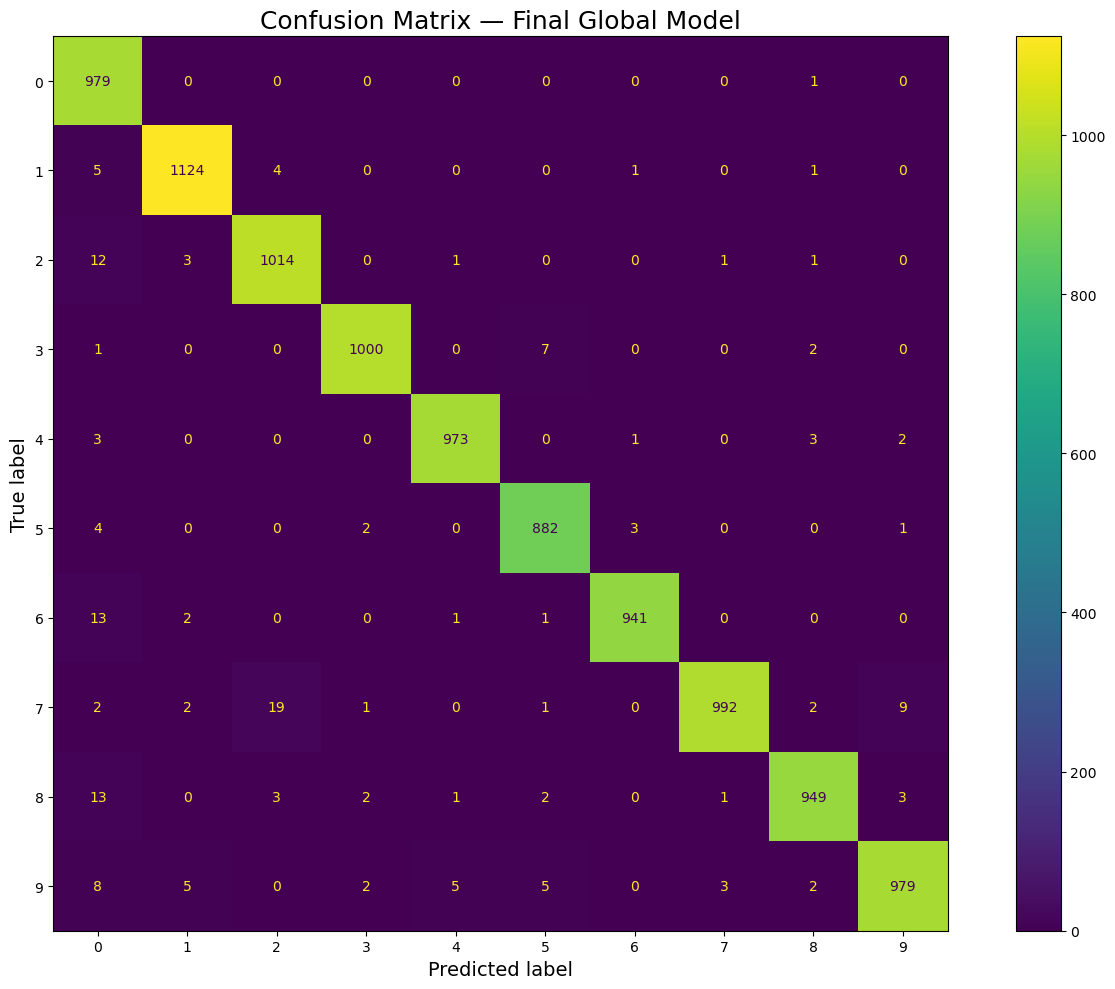

In [42]:
# ==============================================================
# Confusion Matrix of the Final Global Model
# ==============================================================

# Get true labels and predictions
(y_true, y_pred), _ = evaluate_model(
    final_global_model,
    testset,
    return_predictions=True,
)

# Create confusion matrix
cm = confusion_matrix(
    y_true,
    y_pred,
)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(range(10)),
)

fig, ax = plt.subplots(
    figsize=(14, 10)
)

disp.plot(
    ax=ax,
    cmap="viridis",
    values_format="d",
    colorbar=True,
)

plt.title(
    "Confusion Matrix — Final Global Model",
    fontsize=18,
)

plt.xlabel(
    "Predicted label",
    fontsize=14,
)

plt.ylabel(
    "True label",
    fontsize=14,
)

plt.tight_layout()

plt.show()

### Key Takeaways

- Independent local models developed blind spots because each client had incomplete, non-IID data.

- Federated Learning allowed the clients to share knowledge through model updates without sharing raw images.

- FedAvg combined the knowledge learned by all three clients into one global model.

- The global model achieved better coverage across all digit classes and reduced the missing-class blind spots.

- Federated Learning improves collaboration, but additional techniques may still be required for privacy, communication efficiency, and highly heterogeneous data.

---